# Financial Fraud Detection Analysis 🚨💳

## Project Overview
This project focuses on analyzing financial transaction data to detect fraudulent activities using data science and machine learning techniques.

The project includes:
- Data understanding
- Data cleaning
- Exploratory Data Analysis (EDA)
- Data visualization
- Fraud prediction modeling

Dataset:
- fraudTrain.csv
- fraudTest.csv

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)

print("Libraries imported successfully 🚀")

Libraries imported successfully 🚀


In [ ]:
# Load datasets
train_df = pd.read_csv('../data/fraudTrain.csv')


print("Training dataset loaded successfully!")


Training dataset loaded successfully!
Testing dataset loaded successfully!


In [ ]:
print("Training Dataset Shape:", train_df.shape)


Training Dataset Shape: (1296675, 23)
Testing Dataset Shape: (555719, 23)


In [6]:
train_df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [7]:
# Remove unnecessary column
train_df.drop(columns=['Unnamed: 0'], inplace=True)
test_df.drop(columns=['Unnamed: 0'], inplace=True)

print("Unnamed column removed successfully!")

Unnamed column removed successfully!


## EDA & Feature Engineering

In [8]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 22 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  1296675 non-null  object 
 1   cc_num                 1296675 non-null  int64  
 2   merchant               1296675 non-null  object 
 3   category               1296675 non-null  object 
 4   amt                    1296675 non-null  float64
 5   first                  1296675 non-null  object 
 6   last                   1296675 non-null  object 
 7   gender                 1296675 non-null  object 
 8   street                 1296675 non-null  object 
 9   city                   1296675 non-null  object 
 10  state                  1296675 non-null  object 
 11  zip                    1296675 non-null  int64  
 12  lat                    1296675 non-null  float64
 13  long                   1296675 non-null  float64
 14  city_pop          

In [9]:
train_df.describe()

,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


In [10]:
train_df['is_fraud'].value_counts()

is_fraud
0    1289169
1       7506
Name: count, dtype: int64

In [11]:
# Check duplicate rows

train_df.duplicated().sum()

0

In [12]:
# Convert columns to datetime format

train_df['trans_date_trans_time'] = pd.to_datetime(train_df['trans_date_trans_time'])

train_df['dob'] = pd.to_datetime(train_df['dob'])

print("Datetime formatting completed!")

Datetime formatting completed!


In [13]:
# Create customer age feature

train_df['age'] = 2026 - train_df['dob'].dt.year

print("Age feature created successfully!")

Age feature created successfully!


In [14]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   trans_date_trans_time  1296675 non-null  datetime64[ns]
 1   cc_num                 1296675 non-null  int64         
 2   merchant               1296675 non-null  object        
 3   category               1296675 non-null  object        
 4   amt                    1296675 non-null  float64       
 5   first                  1296675 non-null  object        
 6   last                   1296675 non-null  object        
 7   gender                 1296675 non-null  object        
 8   street                 1296675 non-null  object        
 9   city                   1296675 non-null  object        
 10  state                  1296675 non-null  object        
 11  zip                    1296675 non-null  int64         
 12  lat                    12966

In [15]:
from math import radians, sin, cos, sqrt, atan2

# Function to calculate distance between two coordinates
def haversine(lat1, lon1, lat2, lon2):
    
    # Earth radius in kilometers
    R = 6371
    
    # Convert degrees to radians
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    
    # Differences
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    # Haversine formula
    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    
    # Distance in km
    distance = R * c
    
    return distance

In [16]:
# Create distance feature

train_df['distance_km'] = train_df.apply(
    lambda row: haversine(
        row['lat'],
        row['long'],
        row['merch_lat'],
        row['merch_long']
    ),
    axis=1
)

print("Distance feature created successfully!")

Distance feature created successfully!


In [17]:
train_df.head(200)

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,age,distance_km
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,38,78.597568
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,48,30.212176
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,64,108.206083
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,59,95.673231
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,40,77.556744
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,2019-01-01 02:23:41,3560336828629935,fraud_Abshire PLC,entertainment,65.05,Christopher,White,M,13613 Hammond Ferry,Clutier,IA,52217,42.0789,-92.3763,590,"Embryologist, clinical",1953-03-30,df1f46cb63a40e84702de8c3b0c8f66f,1325384621,41.388862,-91.844621,0,73,88.507675
196,2019-01-01 02:26:14,4364010865167176,fraud_Huels-Hahn,gas_transport,61.99,Gary,Martinez,M,03512 Jackson Ports,Reno,NV,89512,39.5483,-119.7957,276896,Immunologist,1997-03-12,56bf02cc990fffa7866794be63472528,1325384774,38.573952,-120.084189,0,29,111.168697
197,2019-01-01 02:26:16,4334230547694630,fraud_Torp-Labadie,gas_transport,49.53,Scott,Martin,M,7483 Navarro Flats,Freedom,WY,83120,43.0172,-111.0292,471,"Education officer, museum",1967-08-02,c09831d3ebf12b67982f193d03162974,1325384776,43.038723,-111.821595,0,59,64.454670
198,2019-01-01 02:27:58,4469777115158234880,fraud_Funk Group,grocery_net,54.47,Gregory,Graham,M,4005 Dana Glens,Methuen,MA,1844,42.7280,-71.1810,47249,Market researcher,1980-11-22,380323300d81e3748e91db03d95cc3fa,1325384878,42.114749,-70.460861,0,46,90.244400


## Transaction Amount Analysis

The transaction amount distribution is highly right-skewed.

Observations:
- Most transactions are small amounts below $100.
- Large transactions are relatively rare.
- The dataset contains several high-value outliers.

This behavior is common in financial transaction data where small everyday purchases occur more frequently than expensive transactions.

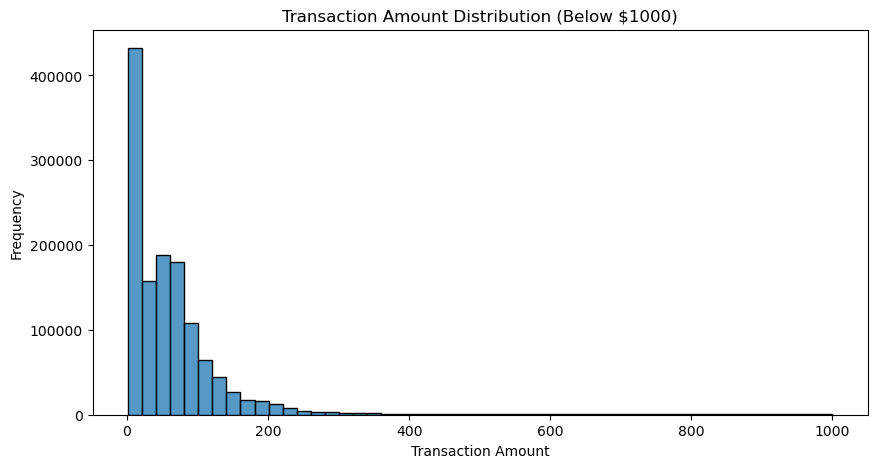

In [18]:
# Transaction amount distribution
# Focus on smaller transaction amounts

plt.figure(figsize=(10,5))

sns.histplot(train_df[train_df['amt'] < 1000]['amt'], bins=50)

plt.title('Transaction Amount Distribution (Below $1000)')

plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')

plt.show()

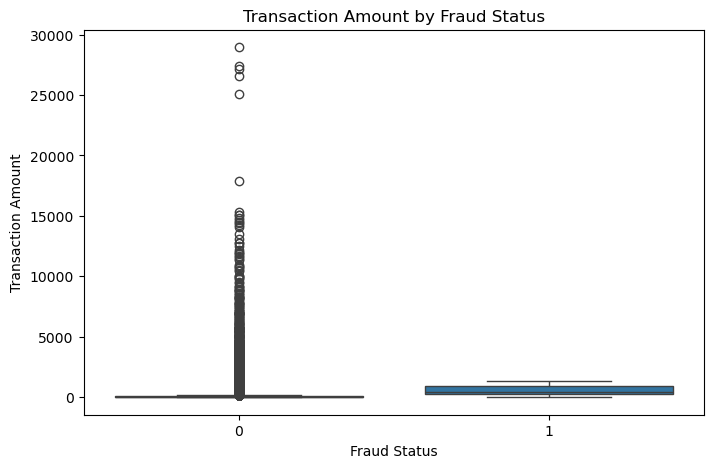

In [19]:
# Compare transaction amounts by fraud status

plt.figure(figsize=(8,5))

sns.boxplot(x='is_fraud', y='amt', data=train_df)

plt.title('Transaction Amount by Fraud Status')

plt.xlabel('Fraud Status')
plt.ylabel('Transaction Amount')

plt.show()

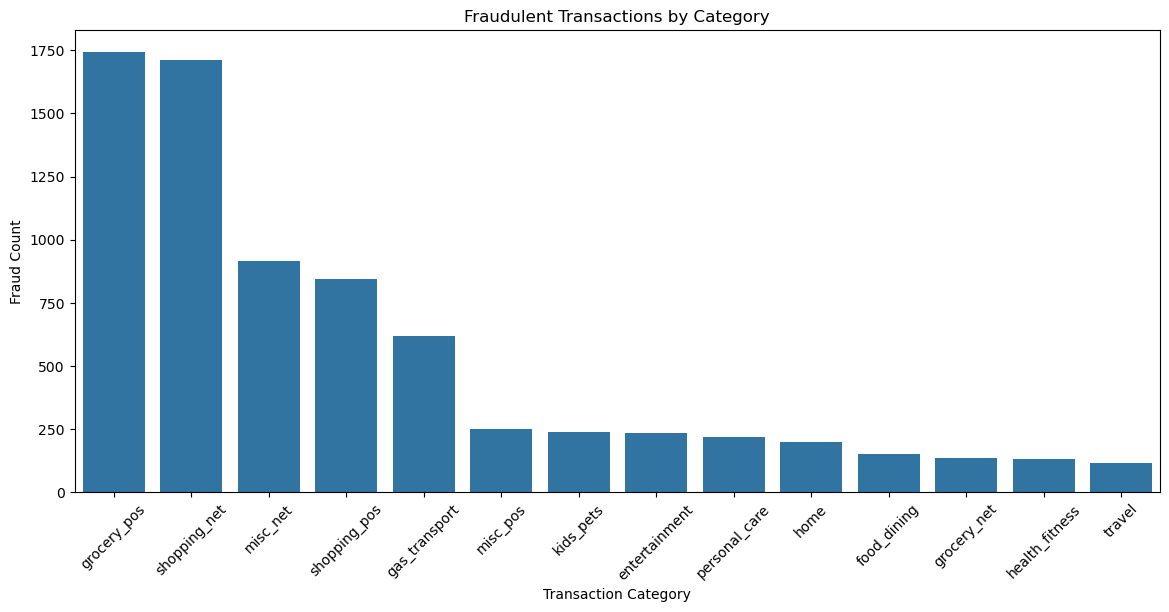

In [20]:
# Filter only fraud transactions
fraud_df = train_df[train_df['is_fraud'] == 1]

# Count fraud transactions by category
fraud_counts = fraud_df['category'].value_counts()

# Plot descending order
plt.figure(figsize=(14,6))

sns.barplot(
    x=fraud_counts.index,
    y=fraud_counts.values
)

plt.title('Fraudulent Transactions by Category')

plt.xlabel('Transaction Category')
plt.ylabel('Fraud Count')

plt.xticks(rotation=45)

plt.show()

## Age Distribution by Fraud Status

The age distributions of fraudulent and non-fraudulent transactions appear relatively similar.

Observations:
- Fraud occurs across a wide range of customer ages.
- Fraudulent transactions show a slightly higher median age.
- There is substantial overlap between both groups.

This suggests that age alone may not be a strong predictor of fraudulent activity.

In [21]:
# Create age groups

bins = [20, 30, 40, 50, 60, 70, 80, 90, 100]

labels = [
    '20-30',
    '30-40',
    '40-50',
    '50-60',
    '60-70',
    '70-80',
    '80-90',
    '90-100'
]

train_df['age_group'] = pd.cut(
    train_df['age'],
    bins=bins,
    labels=labels
)

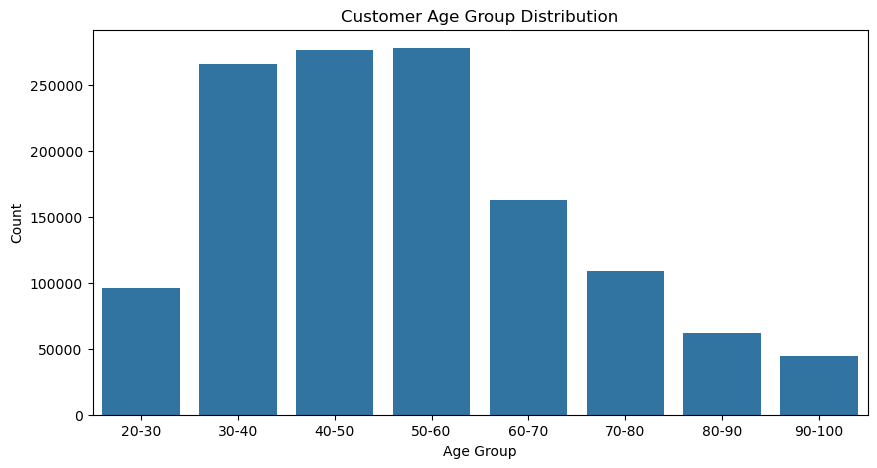

In [22]:
# Plot age group distribution

plt.figure(figsize=(10,5))

sns.countplot(
    data=train_df,
    x='age_group'
)

plt.title('Customer Age Group Distribution')

plt.xlabel('Age Group')
plt.ylabel('Count')

plt.show()

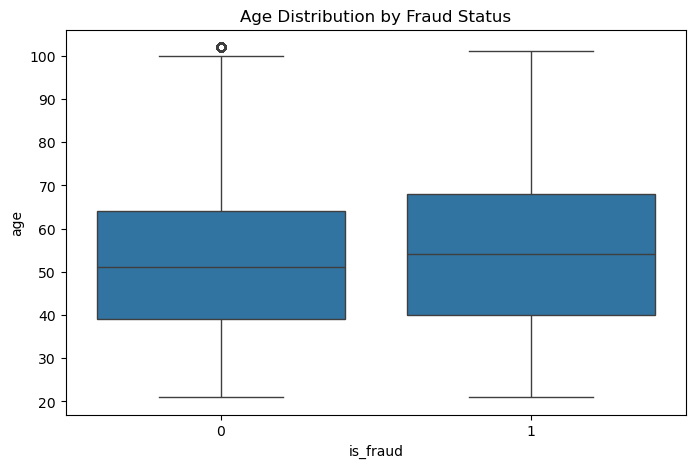

In [23]:
# Age vs fraud

plt.figure(figsize=(8,5))

sns.boxplot(x='is_fraud', y='age', data=train_df)

plt.title('Age Distribution by Fraud Status')

plt.show()

## Distance Analysis

The customer-to-merchant distance distribution appears relatively similar for both fraudulent and non-fraudulent transactions.

Observations:
- Most transaction distances fall between 50 km and 100 km.
- Fraudulent and legitimate transactions show highly overlapping distance distributions.
- Distance alone may not be a strong predictor of fraudulent activity in this dataset.

However, distance may still contribute useful information when combined with other behavioral and transactional features.

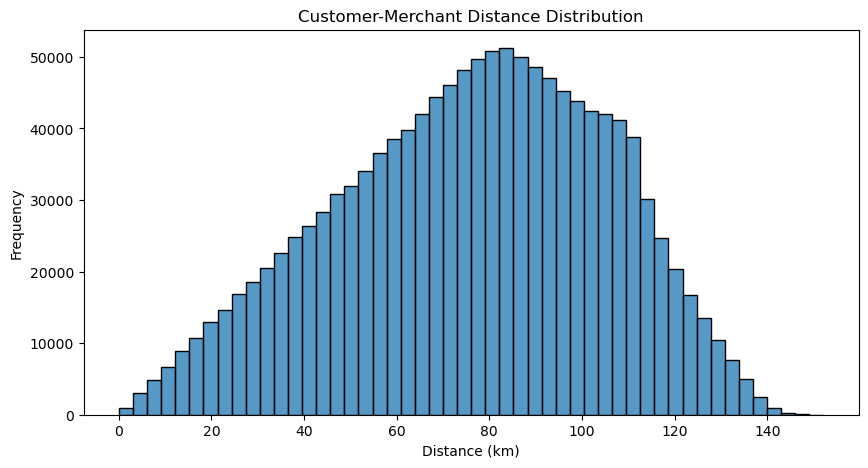

In [24]:
# Distance distribution

plt.figure(figsize=(10,5))

sns.histplot(train_df['distance_km'], bins=50)

plt.title('Customer-Merchant Distance Distribution')

plt.xlabel('Distance (km)')
plt.ylabel('Frequency')

plt.show()

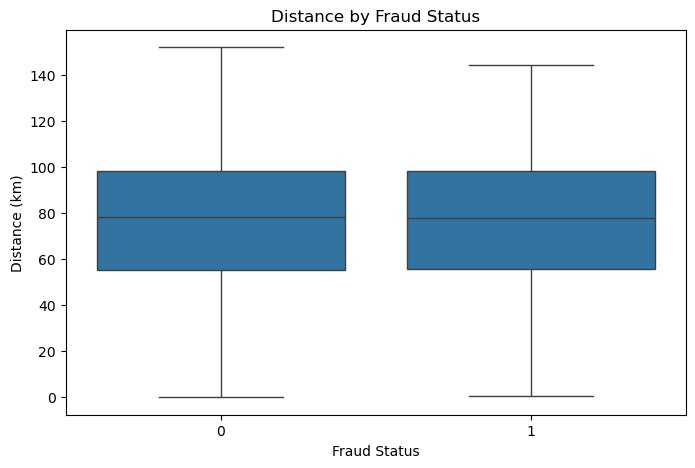

In [25]:
# Distance vs fraud

plt.figure(figsize=(8,5))

sns.boxplot(
    x='is_fraud',
    y='distance_km',
    data=train_df
)

plt.title('Distance by Fraud Status')

plt.xlabel('Fraud Status')
plt.ylabel('Distance (km)')

plt.show()

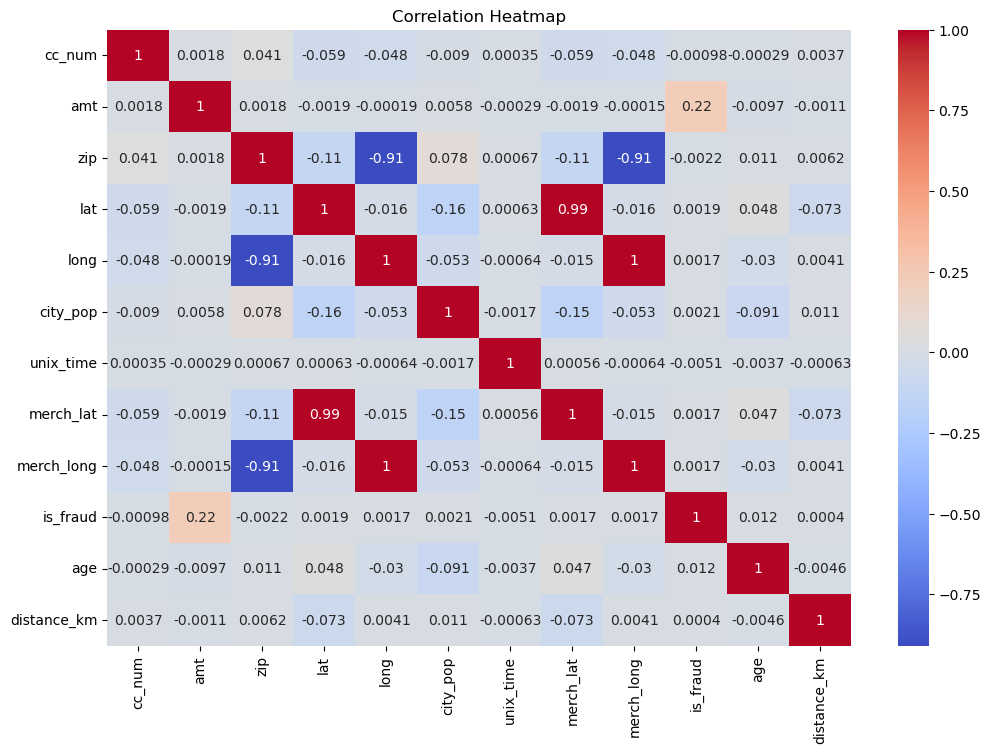

In [26]:
# Correlation heatmap

plt.figure(figsize=(12,8))

sns.heatmap(
    train_df.select_dtypes(include=['number']).corr(),
    cmap='coolwarm',
    annot=True
)

plt.title('Correlation Heatmap')

plt.show()

## Machine learning preparation 


In [31]:
# Remove unnecessary columns

columns_to_drop = [
    'first',
    'last',
    'street',
    'trans_num',
    'cc_num',
    'dob',
    'trans_date_trans_time',
    'age_group'
]

train_df = train_df.drop(
    columns=columns_to_drop,
    errors='ignore'
)

print("Unnecessary columns removed successfully!")

Unnecessary columns removed successfully!


In [32]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 17 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   merchant     1296675 non-null  object 
 1   category     1296675 non-null  object 
 2   amt          1296675 non-null  float64
 3   gender       1296675 non-null  object 
 4   city         1296675 non-null  object 
 5   state        1296675 non-null  object 
 6   zip          1296675 non-null  int64  
 7   lat          1296675 non-null  float64
 8   long         1296675 non-null  float64
 9   city_pop     1296675 non-null  int64  
 10  job          1296675 non-null  object 
 11  unix_time    1296675 non-null  int64  
 12  merch_lat    1296675 non-null  float64
 13  merch_long   1296675 non-null  float64
 14  is_fraud     1296675 non-null  int64  
 15  age          1296675 non-null  int64  
 16  distance_km  1296675 non-null  float64
dtypes: float64(6), int64(5), object(6)
memory usag

In [33]:
# Find categorical columns

categorical_cols = train_df.select_dtypes(include=['object']).columns

print(categorical_cols)

Index(['merchant', 'category', 'gender', 'city', 'state', 'job'], dtype='object')


In [34]:
from sklearn.preprocessing import LabelEncoder

In [35]:
# Apply label encoding

le = LabelEncoder()

for col in categorical_cols:
    train_df[col] = le.fit_transform(train_df[col])

print("Categorical columns encoded successfully!")

Categorical columns encoded successfully!


In [36]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 17 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   merchant     1296675 non-null  int64  
 1   category     1296675 non-null  int64  
 2   amt          1296675 non-null  float64
 3   gender       1296675 non-null  int64  
 4   city         1296675 non-null  int64  
 5   state        1296675 non-null  int64  
 6   zip          1296675 non-null  int64  
 7   lat          1296675 non-null  float64
 8   long         1296675 non-null  float64
 9   city_pop     1296675 non-null  int64  
 10  job          1296675 non-null  int64  
 11  unix_time    1296675 non-null  int64  
 12  merch_lat    1296675 non-null  float64
 13  merch_long   1296675 non-null  float64
 14  is_fraud     1296675 non-null  int64  
 15  age          1296675 non-null  int64  
 16  distance_km  1296675 non-null  float64
dtypes: float64(6), int64(11)
memory usage: 168.2 M

In [37]:
train_df.head()

,merchant,category,amt,gender,city,state,zip,lat,long,city_pop,job,unix_time,merch_lat,merch_long,is_fraud,age,distance_km
0,514,8,4.97,0,526,27,28654,36.0788,-81.1781,3495,370,1325376018,36.011293,-82.048315,0,38,78.597568
1,241,4,107.23,0,612,47,99160,48.8878,-118.2105,149,428,1325376044,49.159047,-118.186462,0,48,30.212176
2,390,0,220.11,1,468,13,83252,42.1808,-112.2620,4154,307,1325376051,43.150704,-112.154481,0,64,108.206083
3,360,2,45.00,1,84,26,59632,46.2306,-112.1138,1939,328,1325376076,47.034331,-112.561071,0,59,95.673231
4,297,9,41.96,1,216,45,24433,38.4207,-79.4629,99,116,1325376186,38.674999,-78.632459,0,40,77.556744


In [38]:
# Define features and target

X = train_df.drop('is_fraud', axis=1)

y = train_df['is_fraud']

print("Features and target created successfully!")

Features and target created successfully!


In [39]:
print(X.shape)

print(y.shape)

(1296675, 16)
(1296675,)


In [40]:
from sklearn.model_selection import train_test_split

In [41]:
# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train-test split completed!")

Train-test split completed!


In [42]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(1037340, 16)
(259335, 16)
(1037340,)
(259335,)


# Handling Imbalanced Data

The dataset used in this project is highly imbalanced, where legitimate transactions significantly outnumber fraudulent transactions. This imbalance can negatively affect machine learning models because the model may become biased toward predicting the majority class (non-fraud) while failing to correctly identify fraudulent transactions.

To address this issue, SMOTE (Synthetic Minority Oversampling Technique) was applied to the training dataset. SMOTE generates synthetic samples for the minority class instead of simply duplicating existing fraud cases, helping the model learn fraud patterns more effectively.

The imbalance handling process was applied only to the training data after performing the train-test split in order to avoid data leakage and preserve realistic evaluation on unseen test data.


In [ ]:
!pip install imbalanced-learn



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [44]:
from imblearn.over_sampling import SMOTE
# Apply SMOTE on training data only

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("SMOTE applied successfully!")

SMOTE applied successfully!


In [45]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
is_fraud
0    1031335
1       6005
Name: count, dtype: int64

After SMOTE:
is_fraud
0    1031335
1    1031335
Name: count, dtype: int64


# Feature Scaling 

In [46]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Scale features

X_train_scaled = scaler.fit_transform(X_train_smote)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [47]:
print(X_train_scaled.shape)

print(X_test_scaled.shape)

(2062670, 16)
(259335, 16)


# Model

In [48]:
from sklearn.linear_model import LogisticRegression
# Create logistic regression model

model = LogisticRegression(random_state=42)
# Train model

model.fit(X_train_scaled, y_train_smote)

print("Model trained successfully!")

Model trained successfully!


In [49]:
# Predict on test data

y_pred = model.predict(X_test_scaled)

In [50]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Logistic Regression Evaluation

The Logistic Regression model achieved high recall in detecting fraudulent transactions.

Results:
- Accuracy: 94.47%
- Precision: 7.60%
- Recall: 76.62%
- F1-Score: 13.83%

Key observations:
- The model successfully detected a large proportion of fraud cases.
- Recall performance is strong, which is important in fraud detection systems.
- However, precision is relatively low, indicating a high number of false positive predictions.

This suggests that the model prioritizes detecting fraud over minimizing false alarms.

In [51]:
# Evaluation metrics

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)

print("Precision:", precision)

print("Recall   :", recall)

print("F1-Score :", f1)

Accuracy : 0.9447471417278809
Precision: 0.07601797990481227
Recall   : 0.7661558960692871
F1-Score : 0.13831258644536654


In [52]:
# Confusion matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[243856  13978]
 [   351   1150]]


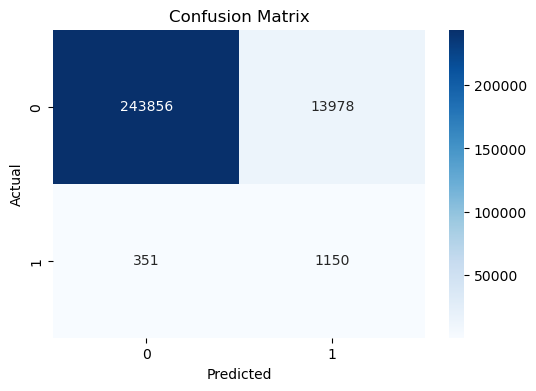

In [53]:
# Plot confusion matrix

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

# Fine Tuning

In [54]:
from sklearn.ensemble import RandomForestClassifier

In [55]:
# Create Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [56]:
# Train Random Forest

rf_model.fit(X_train_smote, y_train_smote)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [57]:
# Predict using Random Forest

rf_pred = rf_model.predict(X_test)

print("Predictions completed!")

Predictions completed!


In [58]:
# Random Forest evaluation

rf_accuracy = accuracy_score(y_test, rf_pred)

rf_precision = precision_score(y_test, rf_pred)

rf_recall = recall_score(y_test, rf_pred)

rf_f1 = f1_score(y_test, rf_pred)

print("Random Forest Results:\n")

print("Accuracy :", rf_accuracy)

print("Precision:", rf_precision)

print("Recall   :", rf_recall)

print("F1-Score :", rf_f1)

Random Forest Results:

Accuracy : 0.9934601962712322
Precision: 0.4604783137413863
Recall   : 0.7568287808127915
F1-Score : 0.5725806451612904


In [59]:
# Confusion matrix

rf_cm = confusion_matrix(y_test, rf_pred)

print(rf_cm)

[[256503   1331]
 [   365   1136]]


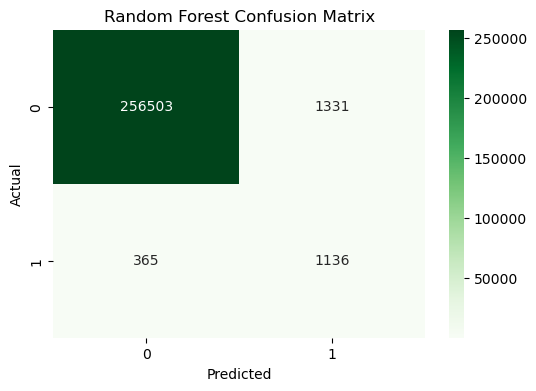

In [60]:
# Plot confusion matrix

plt.figure(figsize=(6,4))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title('Random Forest Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

In [61]:
# Compare models

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy, rf_accuracy],
    'Precision': [precision, rf_precision],
    'Recall': [recall, rf_recall],
    'F1-Score': [f1, rf_f1]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.944747,0.076018,0.766156,0.138313
1,Random Forest,0.993460,0.460478,0.756829,0.572581


In [62]:
# Feature importance

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance

,Feature,Importance
0,merchant,0.030167
1,category,0.083765
2,amt,0.622860
3,gender,0.006722
4,city,0.019830
5,state,0.014253
6,zip,0.017100
7,lat,0.017694
8,long,0.016267
9,city_pop,0.024406


In [63]:
# Sort feature importance

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
2,amt,0.622860
1,category,0.083765
11,unix_time,0.046934
0,merchant,0.030167
9,city_pop,0.024406
14,age,0.022414
10,job,0.021884
4,city,0.019830
13,merch_long,0.018880
12,merch_lat,0.018453


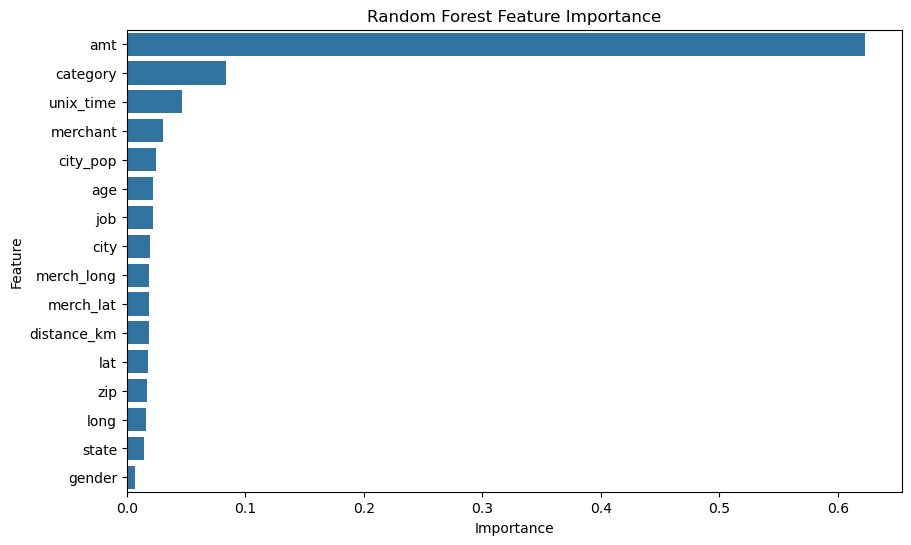

In [64]:
# Plot feature importance

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title('Random Forest Feature Importance')

plt.show()

In [70]:
from sklearn.model_selection import GridSearchCV
# Parameters to test

param_grid = {
    'n_estimators': [100, 200],

    'max_depth': [10, 20],

    'min_samples_split': [2],

    'min_samples_leaf': [1]
}

In [71]:
# Grid Search

grid_search = GridSearchCV(

    estimator=RandomForestClassifier(random_state=42),

    param_grid=param_grid,

    cv=3,

    scoring='f1',

    n_jobs=-1,

    verbose=2
)

In [73]:
X_sample = X_train_smote.sample(200000, random_state=42)

y_sample = y_train_smote.loc[X_sample.index]

In [74]:
grid_search.fit(X_sample, y_sample)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time= 1.2min
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time= 1.2min
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time= 1.2min
[CV] END max_depth=20, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time= 2.0min
[CV] END max_depth=20, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time= 2.0min
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time= 2.4min
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time= 2.4min
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time= 2.4min
[CV] END max_depth=20, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time= 1.7min
[CV] END max_depth=20, min_samp

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20], 'min_samples_leaf': [1],
                         'min_samples_split': [2], 'n_estimators': [100, 200]},
             scoring='f1', verbose=2)

In [75]:
# Best tuned model

best_rf = grid_search.best_estimator_

# Predictions

best_preds = best_rf.predict(X_test)

# Metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

best_accuracy = accuracy_score(y_test, best_preds)

best_precision = precision_score(y_test, best_preds)

best_recall = recall_score(y_test, best_preds)

best_f1 = f1_score(y_test, best_preds)

# Print results

print("Tuned Random Forest Results")
print()

print("Accuracy :", best_accuracy)

print("Precision:", best_precision)

print("Recall   :", best_recall)

print("F1-Score :", best_f1)

Tuned Random Forest Results

Accuracy : 0.9780399868895444
Precision: 0.1885951885951886
Recall   : 0.8461025982678214
F1-Score : 0.3084395871281117


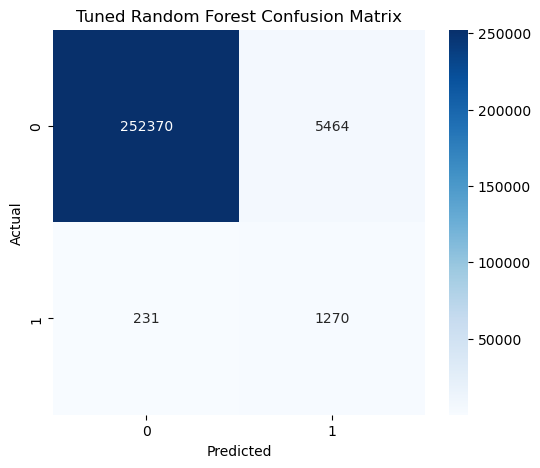

In [76]:
# Confusion Matrix

best_cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    best_cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Tuned Random Forest Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

In [80]:
# Compare all models

comparison = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Tuned Random Forest'
    ],

    'Accuracy': [
        accuracy,
        rf_accuracy,
        best_accuracy
    ],

    'Precision': [
        precision,
        rf_precision,
        best_precision
    ],

    'Recall': [
        recall,
        rf_recall,
        best_recall
    ],

    'F1-Score': [
        f1,
        rf_f1,
        best_f1
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.944747,0.076018,0.766156,0.138313
1,Random Forest,0.993460,0.460478,0.756829,0.572581
2,Tuned Random Forest,0.978040,0.188595,0.846103,0.308440


In [81]:
comparison.sort_values(
    by='F1-Score',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1-Score
1,Random Forest,0.993460,0.460478,0.756829,0.572581
2,Tuned Random Forest,0.978040,0.188595,0.846103,0.308440
0,Logistic Regression,0.944747,0.076018,0.766156,0.138313


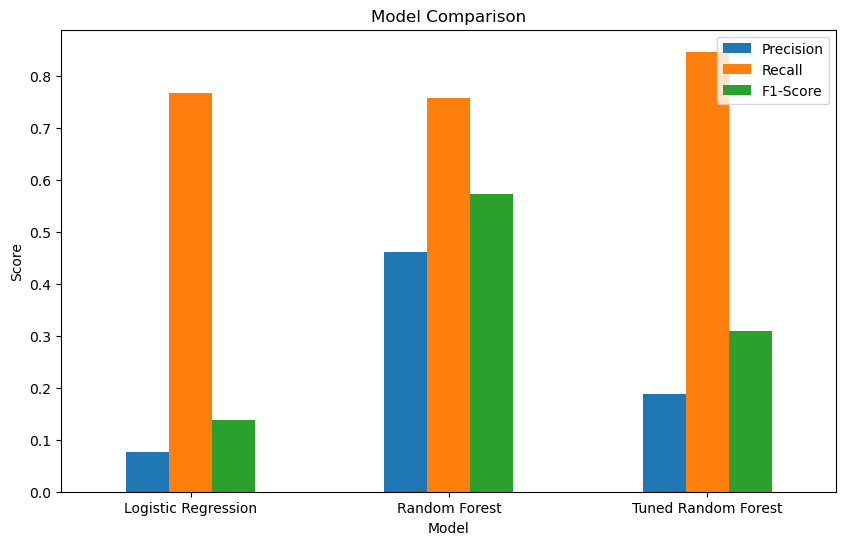

In [82]:
# Visual comparison

comparison.set_index('Model')[
    ['Precision', 'Recall', 'F1-Score']
].plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Model Comparison')

plt.ylabel('Score')

plt.xticks(rotation=0)

plt.show()

# Final Conclusion

This project focused on detecting fraudulent financial transactions using machine learning techniques on a highly imbalanced financial dataset.

The project workflow included:

* Data cleaning and preprocessing
* Feature engineering
* Exploratory Data Analysis (EDA)
* Handling class imbalance using SMOTE
* Building and evaluating multiple machine learning models

During preprocessing, unnecessary columns were removed, categorical variables were encoded, and new features such as customer age and customer-to-merchant distance were engineered.

EDA revealed several important insights:

* The dataset was highly imbalanced with very few fraudulent transactions.
* Transaction amount was strongly associated with fraud.
* Transaction category also showed meaningful fraud patterns.
* Features such as age and distance showed relatively weak relationships with fraud.

A baseline Logistic Regression model was first implemented to establish initial performance. Although the model achieved high recall, it suffered from very low precision, producing many false positive fraud predictions.

A Random Forest classifier was then implemented, significantly improving model performance. The Random Forest model achieved a much better balance between precision and recall while maintaining strong fraud detection capability.

Feature importance analysis showed that:

* Transaction amount (`amt`) was the most influential feature.
* Transaction category and transaction timing also contributed strongly to fraud prediction.
* Geographic and demographic features had lower importance.

Hyperparameter tuning using GridSearchCV was also performed. While tuning improved recall, it reduced precision and overall F1-score, leading to excessive false positives. Therefore, the original Random Forest model was selected as the final model because it provided the best overall balance between fraud detection performance and false alarm reduction.

Final selected model:

* Random Forest Classifier

Final selected model performance:

* Accuracy: 99.34%
* Precision: 46.0%
* Recall: 75.7%
* F1-Score: 57.3%

This project demonstrates a complete end-to-end machine learning workflow for fraud detection, including preprocessing, feature engineering, imbalance handling, model building, evaluation, and optimization.
